# Machine Learning Final Project
## Implementing Linear Regression & Logistic Regression from Scratch

**Student:** Basmala Mohammed Fatooh  
**Instructor:** Dr. Thaer Sahmoud

---

## Dataset
### `Used_Cars.csv` — 4,340 used car records

## Algorithms

**1. Linear Regression**
Target column: `selling_price` — Continuous numerical

**2. Logistic Regression**
Target column: `Premium_car` — Binary (1 = Expensive, 0 = Cheap)

---

All other columns (`name`, `year`, `km_driven`, `fuel`, `seller_type`, `owner`, `transmission`, and — depending on the task — `Premium_car` or `selling_price`) are used as predictive features.

## Notebook structure
1. Task 1 — Data Preprocessing
2. Task 2 — Linear Regression (custom, from scratch)
3. Task 3 — Logistic Regression (custom, from scratch)
4. Task 4 — Overall Comparison (custom vs. scikit-learn)

# 1. Load & Inspect the Data

In [1]:
#import Librares
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
#Load and viwe the data
data_path = r"C:\Users\hp\Desktop\ML Labs\project\Used Cars.csv"
data_set = pd.read_csv(data_path)
print(f"Shape:{data_set.shape}")  #(4340 rows, 8 column)

Shape:(4340, 8)


In [3]:
data_set.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [4]:
#Information Of data (data type and num of null values) 
data_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [5]:
print("null rows:", data_set.isnull().sum())
#The dataset has no missing values so we don't need to handel missing values

null rows: name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64


In [6]:
print("Duplicate rows:", data_set.duplicated().sum())
#Duplicate rows: 763 so we will drop duplicated 

Duplicate rows: 763


# Task 1 — Data Preprocessing

### 1.A Handelling Missing Data

In [7]:
# we don't have missing but if we have we handel in this way 
# for num columns we use mean
num_col = ["year", "selling_price", "km_driven"]
data_set[num_col] = data_set[num_col].fillna(data_set[num_col].mean())

# for categorical columns mode
cat_col = ["fuel", "seller_type", "transmission", "owner"]
data_set[cat_col] = data_set[cat_col].fillna(data_set[cat_col].mode().iloc[0])

data_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [8]:
#drop duplicated 
data_set = data_set.drop_duplicates().reset_index(drop=True) #To adjust the index
print("Shape after dropping duplicates:", data_set.shape)

Shape after dropping duplicates: (3577, 8)


# 1.1 Featuer Engineering 

In [9]:
#Adding a column of the brand by taking the first name from the name of the car to take the name of manufacturer
data_set['brand'] = data_set['name'].str.split().str[0]

In [10]:
from datetime import datetime

# Adding Age of car column
current_year = datetime.now().year
data_set['car_age'] = current_year - data_set['year']
data_set.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,brand,car_age
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner,Maruti,19
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner,Maruti,19
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner,Hyundai,14
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner,Datsun,9
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner,Honda,12


In [11]:
data_set["brand"].value_counts()

brand
Maruti           1072
Hyundai           637
Mahindra          328
Tata              308
Ford              220
Honda             216
Toyota            170
Chevrolet         151
Renault           110
Volkswagen         93
Nissan             52
Skoda              49
Fiat               32
Audi               31
Datsun             29
BMW                25
Mercedes-Benz      21
Mitsubishi          5
Jaguar              5
Land                5
Volvo               4
Jeep                3
Ambassador          3
OpelCorsa           2
MG                  2
Force               1
Daewoo              1
Isuzu               1
Kia                 1
Name: count, dtype: int64

In [12]:
#we Keep the most popular brands and the lesser-known storage in other
data_set['brand'] = data_set['name'].str.split().str[0]
top_brands = data_set['brand'].value_counts().nlargest(8).index
data_set['brand'] = data_set['brand'].where(data_set['brand'].isin(top_brands), 'Other')

print(data_set['brand'].value_counts())

brand
Maruti       1072
Hyundai       637
Other         475
Mahindra      328
Tata          308
Ford          220
Honda         216
Toyota        170
Chevrolet     151
Name: count, dtype: int64


In [13]:
data_set["fuel"].value_counts()
#the most popular is (Diesel and Petrol)

fuel
Diesel      1800
Petrol      1717
CNG           37
LPG           22
Electric       1
Name: count, dtype: int64

In [14]:
#we Keep the most popular fuel and the lesser-known storage in other
data_set["fuel"] = data_set["fuel"].where(data_set["fuel"].isin(["Diesel", "Petrol"]), "Other")
print(data_set["fuel"].value_counts())

fuel
Diesel    1800
Petrol    1717
Other       60
Name: count, dtype: int64


In [15]:
data_set.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,brand,car_age
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner,Maruti,19
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner,Maruti,19
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner,Hyundai,14
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner,Other,9
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner,Honda,12


## 1.2 Handling Outliers

In [16]:
num_col = ['selling_price', 'km_driven','car_age']   
print(data_set[num_col].describe())

       selling_price      km_driven      car_age
count   3.577000e+03    3577.000000  3577.000000
mean    4.739125e+05   69250.545709    13.037462
std     5.093018e+05   47579.940016     4.251759
min     2.000000e+04       1.000000     6.000000
25%     2.000000e+05   36000.000000    10.000000
50%     3.500000e+05   60000.000000    13.000000
75%     6.000000e+05   90000.000000    16.000000
max     8.900000e+06  806599.000000    34.000000


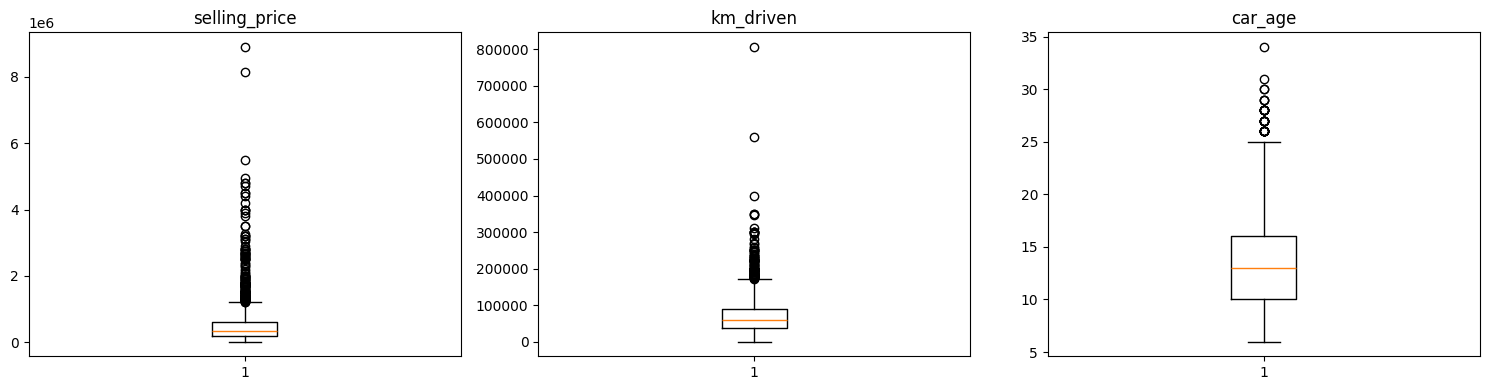

In [17]:
plt.figure(figsize=(15,4))   #Big figure shows three plots
for i, col in enumerate(num_col):
    plt.subplot(1, len(num_col), i+1)  #1 first figure => i+1 next figure
    plt.boxplot(data_set[col])         #plot boxplot
    plt.title(col)

plt.tight_layout()    #Spacing arrangement to avoid overlapping headings
plt.show()

In [18]:
# Handel Outliers using IQR 
for col in num_col:
    Q1 = data_set[col].quantile(0.25)      #first quartile (Q1)
    Q3 = data_set[col].quantile(0.75)      #third quartile (Q3)

    IQR = Q3 - Q1         #Interquartile Range (IQR)

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Filter the data column by removing outliers
    data_set = data_set[(data_set[col] >= lower_bound) & (data_set[col] <= upper_bound)]

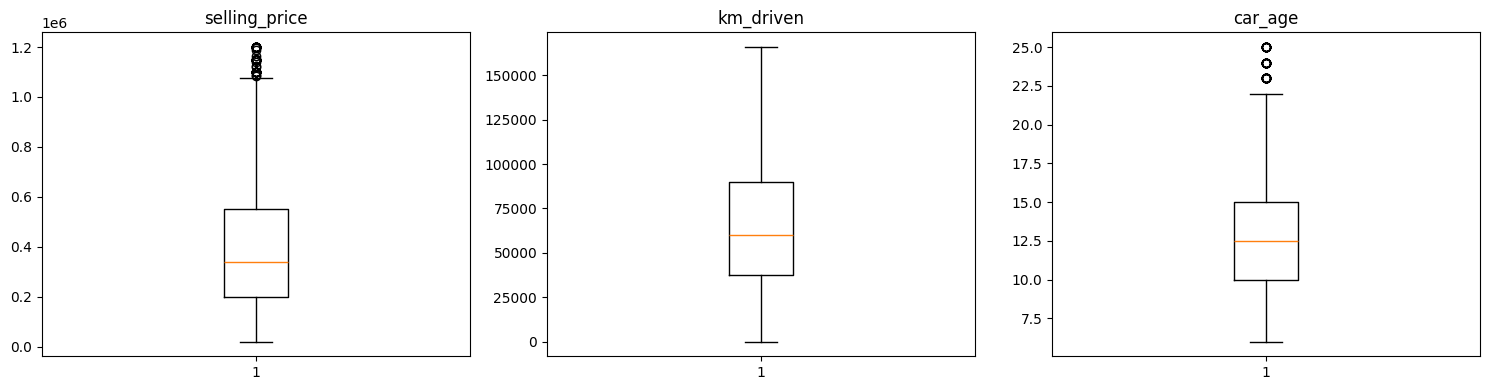

In [19]:
# Visualize numerical columns after outlier handling
plt.figure(figsize=(15,4))   
for i, col in enumerate(num_col):
    plt.subplot(1, len(num_col), i+1)  
    plt.boxplot(data_set[col])         
    plt.title(col)

plt.tight_layout()   
plt.show()

## 1.C Handling Categorical Data

In [20]:
print(data_set["seller_type"].unique())
print(data_set["brand"].unique())
print(data_set["fuel"].unique())

['Individual' 'Dealer' 'Trustmark Dealer']
['Maruti' 'Hyundai' 'Other' 'Honda' 'Tata' 'Chevrolet' 'Toyota' 'Mahindra'
 'Ford']
['Petrol' 'Diesel' 'Other']


In [21]:
#Every text value gets converted into a number that reflects its logical order
owner_map = {
    'Test Drive Car': 0,
    'First Owner': 1,
    'Second Owner': 2,
    'Third Owner': 3,
    'Fourth & Above Owner': 4,
}

data_set['owner'] = data_set['owner'].map(owner_map) #Replace all the text with its corresponding number

data_set['transmission'] = data_set['transmission'].map({'Manual': 0, 'Automatic': 1})

# Convert unordered categorical columns (there's no logical order between them) into 0/1 columns 
data_set = pd.get_dummies(data_set, columns=['brand', 'fuel', 'seller_type'], drop_first=True)  #(One-Hot)

# Get the column names that came out as bool (True/False) after get_dummies
bool_cols = data_set.select_dtypes(include='bool').columns
data_set[bool_cols] = data_set[bool_cols].astype(int)  #0 ,1 

print(data_set.shape)
data_set.head()

(3250, 19)


,name,year,selling_price,km_driven,transmission,owner,car_age,brand_Ford,brand_Honda,brand_Hyundai,brand_Mahindra,brand_Maruti,brand_Other,brand_Tata,brand_Toyota,fuel_Other,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer
0,Maruti 800 AC,2007,60000,70000,0,1,19,0,0,0,0,1,0,0,0,0,1,1,0
1,Maruti Wagon R LXI Minor,2007,135000,50000,0,1,19,0,0,0,0,1,0,0,0,0,1,1,0
2,Hyundai Verna 1.6 SX,2012,600000,100000,0,1,14,0,0,1,0,0,0,0,0,0,0,1,0
3,Datsun RediGO T Option,2017,250000,46000,0,1,9,0,0,0,0,0,1,0,0,0,1,1,0
4,Honda Amaze VX i-DTEC,2014,450000,141000,0,2,12,0,1,0,0,0,0,0,0,0,0,1,0


In [22]:
# in the next step in traning we don't have columns of name and year so we want to drop it 
data_set = data_set.drop(columns = ["name", "year"])
data_set.head()

,selling_price,km_driven,transmission,owner,car_age,brand_Ford,brand_Honda,brand_Hyundai,brand_Mahindra,brand_Maruti,brand_Other,brand_Tata,brand_Toyota,fuel_Other,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer
0,60000,70000,0,1,19,0,0,0,0,1,0,0,0,0,1,1,0
1,135000,50000,0,1,19,0,0,0,0,1,0,0,0,0,1,1,0
2,600000,100000,0,1,14,0,0,1,0,0,0,0,0,0,0,1,0
3,250000,46000,0,1,9,0,0,0,0,0,1,0,0,0,1,1,0
4,450000,141000,0,2,12,0,1,0,0,0,0,0,0,0,0,1,0


## Defining Targets & Train/Test Split   ==> 80% train and 20% test

In [23]:
# Premium = above the average price
threshold = data_set["selling_price"].mean()

data_set["Premium_car"] = (data_set["selling_price"] > threshold).astype(int)

print(f"Threshold price = {threshold}")
print(data_set["Premium_car"].value_counts())

Threshold price = 395974.2067692308
Premium_car
0    1860
1    1390
Name: count, dtype: int64


In [24]:
from sklearn.model_selection import train_test_split # only used for the split itself, not modeling
 
# Let's remove both from the features in both cases to prevent Data Leakage
#x_reg = x_clf
x = data_set.drop(columns=["selling_price", "Premium_car"])   # The same features for both

y_reg = data_set["selling_price"]   # Linear Regression Target
y_clf = data_set["Premium_car"]     # Logistic Regression Target

# Linear regression splits
x_reg_tr , x_reg_test, y_reg_tr, y_reg_test = train_test_split(x, y_reg, test_size = 0.2 , random_state=42)

# Logistic regression splits
x_clf_tr , x_clf_test, y_clf_tr , y_clf_test = train_test_split(x, y_clf, test_size = 0.2 , random_state=42)

print("Regression => train:", x_reg_tr.shape, " test:", x_reg_test.shape)
print("Classification => train:", x_clf_tr.shape, " test:", x_clf_test.shape)

Regression => train: (2600, 16)  test: (650, 16)
Classification => train: (2600, 16)  test: (650, 16)


## 1.D Try different normalization (MinMax normalization – Z-score standerization)
### to avoid data leakage. Z-score standardization is the variant used for the "with normalization" models (B and C), since it is well-behaved for gradient-based optimization regardless of a feature's original scale.

### Staneraization  (Z-score)
* x_new = x_old - x.mean() / x.std()

In [68]:
# Normalization (Min-Max) => same data used for both regression and classification
x_tr_minmax = (x_reg_tr - x_reg_tr.min()) / (x_reg_tr.max() - x_reg_tr.min())
x_test_minmax = (x_reg_test - x_reg_tr.min()) / (x_reg_tr.max() - x_reg_tr.min())

In [25]:
# Normalization (Z-score) => same data used for both regression and classification
x_tr_norm = (x_reg_tr - x_reg_tr.mean()) / x_reg_tr.std()
x_test_norm = (x_reg_test - x_reg_tr.mean()) / x_reg_tr.std()

## 1.E Apply Principal Component Analysis (PCA) to retain 95% of the original data variance 

In [26]:
#PCA For Traning Data Only  
from sklearn.decomposition import PCA
pca_1 = PCA() 
pca_tr = pca_1.fit(x_tr_norm)

pca_tr_df = pd.DataFrame(pca_tr.components_.T)

#names for rows and columns 
pca_col_name = [f"PC{i+1}" for i in range(pca_tr_df.shape[1])]
pca_tr_df = pd.DataFrame(pca_tr.components_.T, columns=pca_col_name, index = x.columns)
pca_tr_df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16
km_driven,0.529447,-0.139185,-0.034567,0.191405,-0.074065,-0.053791,-0.019462,-0.009608,0.060816,0.033334,-0.072444,-0.192031,0.432178,-0.210126,0.612996,0.001855
transmission,-0.170558,-0.059514,0.137835,0.392335,0.286204,-0.150298,-0.043951,-0.018695,0.077015,0.213369,0.773920,0.012096,0.175866,-0.070811,-0.033466,-0.006264
owner,0.468234,0.143018,0.112087,0.214252,-0.054017,-0.062770,0.019482,-0.114841,0.000602,0.120501,0.084944,0.288706,-0.278161,0.701268,0.084636,-0.003083
car_age,0.477037,0.209013,0.104925,0.274988,-0.141741,0.054837,0.039037,-0.096713,0.032432,0.137419,-0.027820,-0.279001,-0.190911,-0.398262,-0.560461,0.020470
brand_Ford,-0.028366,-0.233539,-0.097361,0.065040,-0.329538,0.043114,0.758452,-0.112137,-0.109346,-0.015346,0.142806,0.307334,-0.057384,-0.166132,0.039492,0.270507
brand_Honda,-0.147681,-0.092131,-0.002986,0.280197,-0.288052,0.267942,-0.371113,-0.394433,0.462010,-0.294461,-0.043431,0.216884,0.094345,-0.009573,-0.047963,0.287638
brand_Hyundai,-0.091381,0.124254,0.667215,-0.212304,-0.261697,-0.346923,-0.021117,0.066195,-0.009032,0.130394,-0.071531,-0.079612,0.240542,0.074812,-0.035523,0.446134
brand_Mahindra,0.121793,-0.362842,-0.132130,-0.315547,0.116392,-0.211389,-0.304416,-0.455390,-0.224660,0.197234,0.117860,-0.062672,-0.376204,-0.148155,0.101574,0.311791
brand_Maruti,-0.003597,0.531485,-0.566809,-0.024707,0.117625,-0.087758,0.044322,-0.025918,-0.044162,0.013549,0.059536,-0.134190,0.231710,0.133104,-0.043629,0.523888
brand_Other,-0.047426,-0.206880,0.143747,0.405991,0.615901,-0.060067,0.137161,0.126103,0.040428,-0.061510,-0.441074,0.036115,-0.139645,-0.018981,0.000176,0.361488


## PCA -keep 95% of the original information-, then train a linear regression and Logistic regewssion

In [27]:
#Comulative Sum
pc_1_info = np.cumsum(pca_tr.explained_variance_ratio_)
pc_1_info
#To reach 95%, we need only 14 PCAs or 13

array([0.13305894, 0.23490126, 0.31874047, 0.39739239, 0.47243027,
       0.54382408, 0.61176098, 0.67794551, 0.7409619 , 0.80038635,
       0.8539671 , 0.89933955, 0.94078471, 0.9749254 , 0.99646859,
       1.        ])

In [28]:
n_components_95 = np.argmax(pc_1_info >= 0.95) + 1
print(n_components_95)   # 14

14


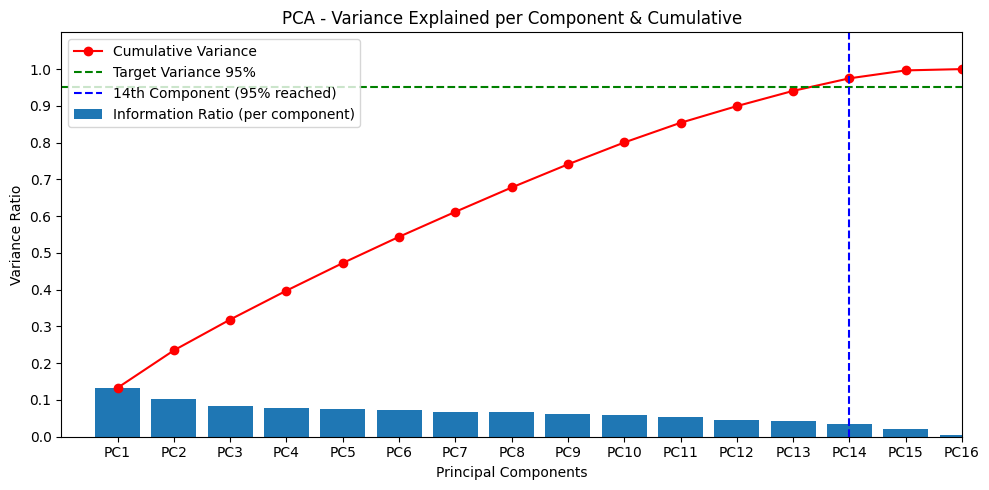

In [29]:
# A figure showing the PCA explained variance and cumulative variance
plt.figure(figsize=(10, 5))
plt.bar(pca_col_name, pca_tr.explained_variance_ratio_, label="Information Ratio (per component)")
plt.plot(pca_col_name, pc_1_info, color="r", marker="o", label="Cumulative Variance")

plt.yticks(np.linspace(0, 1, 11))
plt.ylim(0, 1.1)
plt.xlim(-1, 15)  #16 original components

plt.hlines(y=0.95, xmin=-1, xmax=15, linestyle="dashed", color="g", label="Target Variance 95%")
plt.axvline(x=13, linestyle="dashed", color="b", label="14th Component (95% reached)")

plt.xlabel("Principal Components")
plt.ylabel("Variance Ratio")
plt.title("PCA - Variance Explained per Component & Cumulative")
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
# Final PCA: keep 14 components (95% variance), applied correctly to train AND test
pca = PCA(n_components=14)
x_tr_pca = pca.fit_transform(x_tr_norm)      # fit + transform on Train only
x_test_pca = pca.transform(x_test_norm)      # Just transform (without fitting) on Test

print("Variance retained:", pca.explained_variance_ratio_.sum())
print("Train shape:", x_tr_pca.shape)
print("Test shape:", x_test_pca.shape)

Variance retained: 0.9749253981591679
Train shape: (2600, 14)
Test shape: (650, 14)


## Task 2 — Build Linear Regression Model (from scratch)

## 1. Model A: Baseline Linear Regression
- Implement Linear Regression from scratch using only NumPy, Pandas, and Matplotlib
- (no normalization, no PCA)

In [31]:
# Add Bias column (constant = 1 for every row)

# 1) A copy of the raw data + adding the Bias
x_tr_A = x_reg_tr.copy()
x_test_A = x_reg_test.copy()

if "Bais" not in x_tr_A.columns:
    x_tr_A.insert(loc=0, value=[1]*x_tr_A.shape[0], column="Bais")
if "Bais" not in x_test_A.columns:
    x_test_A.insert(loc=0, value=[1]*x_test_A.shape[0], column="Bais")

In [32]:
#2) Gradient Descent function (Used for both models)
#Error = (y_pred - y)^2
#Error = (xw - y)^2
#dE/dw = (xw - y)*2*x ==>2/m*x*(y_pred - y) => m => number of sampels (x.shape[0])
# Sigmoid not needed here - Linear Regression prediction is just w.x

def grad_dec(x, y, w, lr=0.001):
    y_pred = np.dot(x, w)
    err = y_pred - y
    dw = 2/x.shape[0] * np.dot(err, x)
    w = w - (lr*dw)
    return w

In [33]:
# 3) Training

from tqdm import tqdm
iterations = 30000
w_A = np.zeros(x_tr_A.shape[1])

for i in tqdm(range(iterations)):
    w_A = grad_dec(x_tr_A, y_reg_tr, w_A, lr=0.0000000001)  # lr is very small because the data is raw (km_driven in thousands)

# 4) The evaluation on the test 
pred_A = np.dot(x_test_A, w_A)
mse_A = np.mean((pred_A - y_reg_test)**2)
rmse_A = np.sqrt(mse_A)

print("MSE (Model A):", mse_A)
print("RMSE (Model A):", rmse_A)

100%|██████████| 30000/30000 [00:09<00:00, 3029.95it/s]

MSE (Model A): 124226907607.08682
RMSE (Model A): 352458.3771271252


## 2. Model B: Linear Regression with Normalization 
- Implement Linear Regression from scratch with normalization applied
- Use either Min-Max or Z-score normalization

In [34]:
# Add Bias column to the normalized data
if "Bais" not in x_tr_norm.columns:
    x_tr_norm.insert(loc=0, value=[1]*x_tr_norm.shape[0], column="Bais")
if "Bais" not in x_test_norm.columns:
    x_test_norm.insert(loc=0, value=[1]*x_test_norm.shape[0], column="Bais")

In [35]:
# Training
iterations = 10000
w_B = np.zeros(x_tr_norm.shape[1])   # 1 it's means columns

for i in tqdm(range(iterations)):
    w_B = grad_dec(x_tr_norm, y_reg_tr, w_B, lr=0.01)

# Predict on the normalized test set
pred_B = np.dot(x_test_norm, w_B)
mse_B = np.mean((pred_B - y_reg_test)**2)
rmse_B = np.sqrt(mse_B)

print("MSE (Model B):", mse_B)
print("RMSE (Model B):", rmse_B)

100%|██████████| 10000/10000 [00:03<00:00, 2639.74it/s]

MSE (Model B): 24474599688.911346
RMSE (Model B): 156443.59906660081


## 3. Model C: Linear Regression with Normalization and PCA
- Implement Linear Regression from scratch with both normalization and PCA (95% variance retention)
- Compare performance against Models A and B 

In [36]:
# Add Bias column to the PCA data (numpy array, so we use np.insert instead of pandas .insert)
x_tr_C = np.insert(x_tr_pca, 0, 1, axis=1)  #0 => first column, 1 => the values 1
x_test_C = np.insert(x_test_pca, 0, 1, axis=1)

# Training
iterations = 10000
w_C = np.zeros(x_tr_C.shape[1])

for i in tqdm(range(iterations)):
    w_C = grad_dec(x_tr_C, y_reg_tr, w_C, lr=0.01)

# Predict on the PCA test set
pred_C = np.dot(x_test_C, w_C)
mse_C = np.mean((pred_C - y_reg_test)**2)
rmse_C = np.sqrt(mse_C)

print("MSE (Model C):", mse_C)
print("RMSE (Model C):", rmse_C)

100%|██████████| 10000/10000 [00:00<00:00, 10253.27it/s]

MSE (Model C): 25332558740.1971
RMSE (Model C): 159162.05182202542


## 4. Model Comparison (A, B, C) 
- Compare the performance metrics (e.g., RMSE, R² Score, MAE)
- Analyze the impact of normalization and PCA on regression performance
- Visualize predictions vs. actual values for each model 

### Compare the performance metrics (e.g., RMSE, R² Score, MAE)

In [37]:
# Model A
r2_A = 1 - (np.sum((y_reg_test - pred_A)**2) / np.sum((y_reg_test - y_reg_test.mean())**2))
mae_A = np.mean(np.abs(y_reg_test - pred_A))

# Model B
r2_B = 1 - (np.sum((y_reg_test - pred_B)**2) / np.sum((y_reg_test - y_reg_test.mean())**2))
mae_B = np.mean(np.abs(y_reg_test - pred_B))

# Model C
r2_C = 1 - (np.sum((y_reg_test - pred_C)**2) / np.sum((y_reg_test - y_reg_test.mean())**2))
mae_C = np.mean(np.abs(y_reg_test - pred_C))

In [38]:
comparison_df = pd.DataFrame({
    "Model": ["Model A (baseline)", "Model B (normalized)", "Model C (norm+PCA)"],
    "RMSE": [rmse_A, rmse_B, rmse_C],
    "R2": [r2_A, r2_B, r2_C],
    "MAE": [mae_A, mae_B, mae_C]
})
comparison_df

,Model,RMSE,R2,MAE
0,Model A (baseline),352458.377127,-0.950246,272049.728728
1,Model B (normalized),156443.599067,0.615772,118102.092729
2,Model C (norm+PCA),159162.051822,0.602303,120524.930765


### Analyze the impact of normalization and PCA on regression performance
* First observation: I noticed that normalization was very necessary without it, Model A failed to converge, while Model B managed to achieve better accuracy
* Second observation: When applying PCA in Model C, data complexity decreased, but there was a slight accuracy drop compared to Model B, which reflects the trade-off between speed and information loss.

### Visualize predictions vs. actual values for each model 

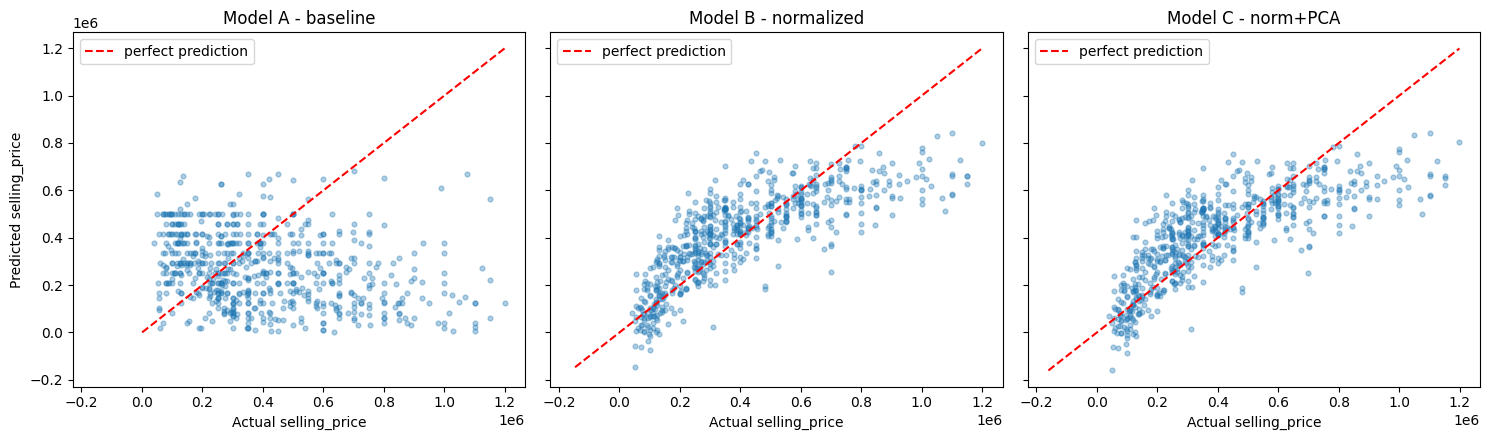

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True, sharey=True)
for ax, pred, name in zip(axes, [pred_A, pred_B, pred_C], ['A - baseline', 'B - normalized', 'C - norm+PCA']):
    ax.scatter(y_reg_test, pred, alpha=0.35, s=12)
    lims = [min(y_reg_test.min(), pred.min()), max(y_reg_test.max(), pred.max())]
    ax.plot(lims, lims, 'r--', label='perfect prediction')
    ax.set_title(f'Model {name}')
    ax.set_xlabel('Actual selling_price')
    ax.legend()
axes[0].set_ylabel('Predicted selling_price')
plt.tight_layout(); plt.show()


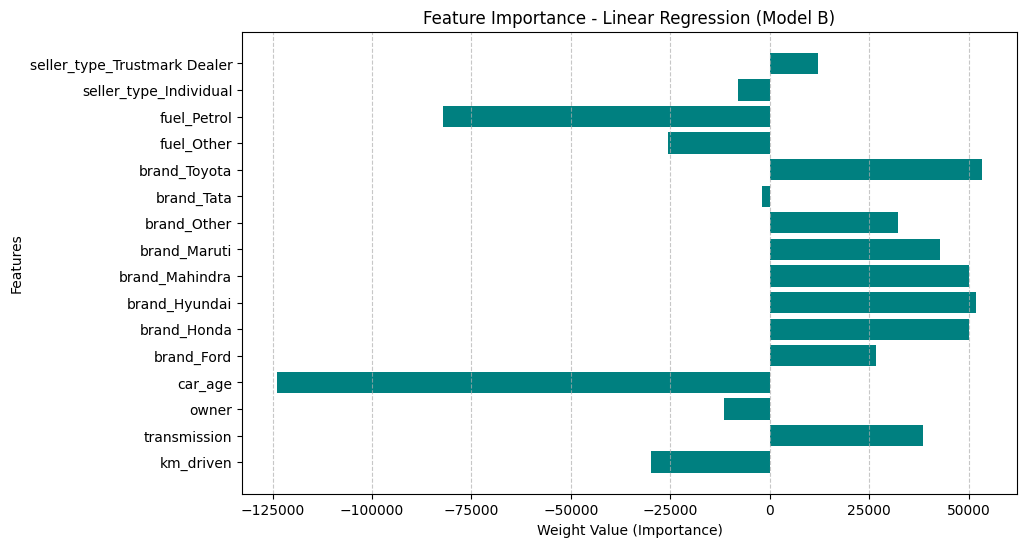

In [40]:
# Drawing weights for model B (Linear Regression)
# We remove the first weight because it represents the Bias
weights = w_B[1:] 
features = x_reg_tr.columns

plt.figure(figsize=(10, 6))
plt.barh(features, weights, color='teal')
plt.xlabel('Weight Value (Importance)')
plt.ylabel('Features')
plt.title('Feature Importance - Linear Regression (Model B)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# Task 3:Build Logistic Regression Model 

## 5. Model A: Baseline Logistic Regression 
- Implement Logistic Regression from scratch using only NumPy, Pandas, and Matplotlib 
- No preprocessing (no normalization, no PCA) 

In [41]:
#Sigmoid Function: It converts any number (z) into a value between 0 and 1 (probability)
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def grad_dec_logistic(x, y, w, lr=0.001):
    z = np.dot(x, w)     # Linear step: z = X.w
    y_pred = sigmoid(z)  # We apply sigmoid to convert z to a probability between 0 and 1
    err = y_pred - y
    dw = (1/x.shape[0]) * np.dot(err, x)
    w = w - (lr * dw)
    return w

In [42]:
# 1) A copy of the raw data (without any edits) - so we don't mess with the original x_clf_tr
x_tr_A_clf = x_clf_tr.copy()
x_test_A_clf = x_clf_test.copy()

# Adding the Bias column (constant value = 1 for each row) as the first column
# The Bias represents the intercept (w0) in the line equation

if "Bais" not in x_tr_A_clf.columns:
    x_tr_A_clf.insert(loc=0, value=[1]*x_tr_A_clf.shape[0], column="Bais")
if "Bais" not in x_test_A_clf.columns:
    x_test_A_clf.insert(loc=0, value=[1]*x_test_A_clf.shape[0], column="Bais")

In [43]:
# 2) Training
from tqdm import tqdm

iterations = 1000
w_clf_A = np.zeros(x_tr_A_clf.shape[1])   # We start with weights = zero (bias + all features)

for i in tqdm(range(iterations)):
    w_clf_A = grad_dec_logistic(x_tr_A_clf, y_clf_tr, w_clf_A, lr=0.0000000001)

100%|██████████| 1000/1000 [00:00<00:00, 2967.15it/s]


In [44]:
# 3) Evaluation on Test Data
z_test = np.dot(x_test_A_clf, w_clf_A)     # The step-by-step on the test
prob_test = sigmoid(z_test)                # Convert it to a probability

# If the probability >= 0.5 we consider it Class 1 (Premium car), otherwise Class 0 (Cheap)
pred_A_clf = (prob_test >= 0.5).astype(int)

# Percentage of correct predictions from the total test data
accuracy_A = np.mean(pred_A_clf == y_clf_test)
print("Accuracy (Model A):", accuracy_A)

Accuracy (Model A): 0.5676923076923077


## 6. Model B: Logistic Regression with Normalization 
- Implement Logistic Regression from scratch with normalization applied
- Use either Min-Max or Z-score normal

In [45]:
# Add the Bias column to the normalized data (if not added yet)

if "Bais" not in x_tr_norm.columns:
    x_tr_norm.insert(loc=0, value=[1]*x_tr_norm.shape[0], column="Bais")
if "Bais" not in x_test_norm.columns:
    x_test_norm.insert(loc=0, value=[1]*x_test_norm.shape[0], column="Bais")

# Training
iterations = 1000
w_clf_B = np.zeros(x_tr_norm.shape[1])   # Let's start with weights = zero

# lr is much larger than Model A because the data is standardized (mean=0, std=1)
for i in tqdm(range(iterations)):
    w_clf_B = grad_dec_logistic(x_tr_norm, y_clf_tr, w_clf_B, lr=0.1)

# Evaluation on test data
z_test_B = np.dot(x_test_norm, w_clf_B)
prob_test_B = sigmoid(z_test_B)

pred_B_clf = (prob_test_B >= 0.5).astype(int)   # >= 0.5 => Class 1 (Premium)

accuracy_B = np.mean(pred_B_clf == y_clf_test)
print("Accuracy (Model B):", accuracy_B)

100%|██████████| 1000/1000 [00:00<00:00, 2417.60it/s]

Accuracy (Model B): 0.8184615384615385


## 7. Model C: Logistic Regression with Normalization and PCA 
- Implement Logistic Regression from scratch with both normalization and PCA (95% variance retention) 
- Compare performance against Models A and B

In [46]:
x_tr_C_clf = np.insert(x_tr_pca, 0, 1, axis=1)
x_test_C_clf = np.insert(x_test_pca, 0, 1, axis=1)

#Training
iterations = 1000
w_clf_C = np.zeros(x_tr_C_clf.shape[1])

for i in tqdm(range(iterations)):
    w_clf_C = grad_dec_logistic(x_tr_C_clf, y_clf_tr, w_clf_C, lr=0.1)


z_test_C = np.dot(x_test_C_clf, w_clf_C)
prob_test_C = sigmoid(z_test_C)

pred_C_clf = (prob_test_C >= 0.5).astype(int)

# Evaluation on test data
accuracy_C = np.mean(pred_C_clf == y_clf_test)
print("Accuracy (Model C):", accuracy_C)

100%|██████████| 1000/1000 [00:00<00:00, 8182.09it/s]

Accuracy (Model C): 0.8184615384615385


## 8. Model Comparison (A, B, C)
- Compare performance metrics (e.g., Accuracy, Precision, Recall, F1-Score)
- Analyze the impact of normalization and PCA on classification performance
- Visualize decision boundaries for each m

### Compare performance metrics (e.g., Accuracy, Precision, Recall, F1-Score)

In [47]:
from sklearn.metrics import confusion_matrix, classification_report

# Model A
print("=== Model A (baseline) ===")
print(confusion_matrix(y_clf_test, pred_A_clf))
print(classification_report(y_clf_test, pred_A_clf, zero_division=0)) #to remove woring

=== Model A (baseline) ===
[[369   0]
 [281   0]]
              precision    recall  f1-score   support

           0       0.57      1.00      0.72       369
           1       0.00      0.00      0.00       281

    accuracy                           0.57       650
   macro avg       0.28      0.50      0.36       650
weighted avg       0.32      0.57      0.41       650



### Model A: Baseline
Model A got **57% accuracy**, but this number is misleading. It predicted *"Cheap"* for every single car and never predicted *"Premium"* even once. As a result, precision, recall, and F1-score for the Premium class were all **0.00**. This happened because the raw data was not normalized, so gradient descent failed to converge properly.


In [48]:
# Model B
print("=== Model B (normalized) ===")
print(confusion_matrix(y_clf_test, pred_B_clf))
print(classification_report(y_clf_test, pred_B_clf))

=== Model B (normalized) ===
[[299  70]
 [ 48 233]]
              precision    recall  f1-score   support

           0       0.86      0.81      0.84       369
           1       0.77      0.83      0.80       281

    accuracy                           0.82       650
   macro avg       0.82      0.82      0.82       650
weighted avg       0.82      0.82      0.82       650



### Model B: Normalization
After applying normalization, performance improved significantly. Accuracy jumped from **57% → 82%**, and the F1-score for the Premium class rose from **0.00 → 0.80**. This shows that normalization was essential for the model to actually learn meaningful patterns from the features.

In [49]:
# Model C
print("=== Model C (norm + PCA) ===")
print(confusion_matrix(y_clf_test, pred_C_clf))
print(classification_report(y_clf_test, pred_C_clf))

=== Model C (norm + PCA) ===
[[298  71]
 [ 47 234]]
              precision    recall  f1-score   support

           0       0.86      0.81      0.83       369
           1       0.77      0.83      0.80       281

    accuracy                           0.82       650
   macro avg       0.82      0.82      0.82       650
weighted avg       0.82      0.82      0.82       650



### Analyze the impact of normalization and PCA on classification performance

### Model C: Normalization + PCA
Model C achieved almost the same results as Model B, with accuracy at **82%** and F1-score at **0.80**. This makes sense: PCA reduced the number of features from 16 to 14 while keeping 95% of the variance. A small amount of information was lost, but the model became simpler and more efficient.

### Overall Summary
- **Normalization** had the biggest impact on model performance.
- **PCA** had almost no effect on accuracy but simplified the model (fewer features).
- **Accuracy alone was misleading** for Model A — precision, recall, and F1-score were needed to reveal the real problem, especially since the classes were imbalanced (57% Cheap vs. 43% Premium).

### Visualize decision boundaries for each model

In [50]:
# Simple function that plots the points and the separating line for any two features
def plot_decision_boundary(x1, x2, y, w0, w1, w2, xlabel, ylabel, title):
    plt.scatter(x1[y==0], x2[y==0], color="r", marker="x", label="Cheap")
    plt.scatter(x1[y==1], x2[y==1], color="g", marker="o", label="Premium")
    
    line_x = np.linspace(x1.min(), x1.max(), 100)
    line_y = -(w0 + w1*line_x) / w2
    plt.plot(line_x, line_y, "b")
    
    plt.ylim(x2.min()-1, x2.max()+1)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.show()

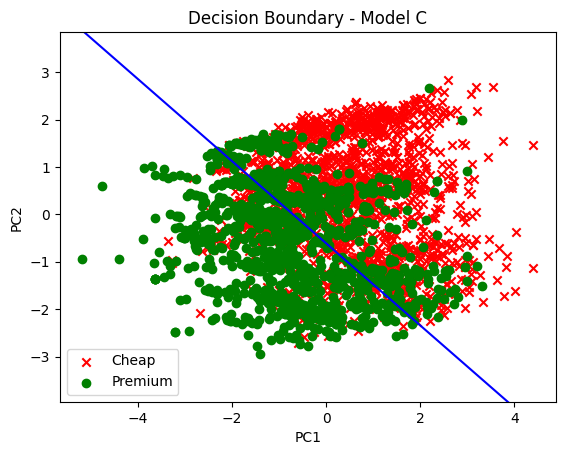

In [51]:
plot_decision_boundary(
    x_tr_C_clf[:,1], x_tr_C_clf[:,2], y_clf_tr.values,
    w_clf_C[0], w_clf_C[1], w_clf_C[2],
    "PC1", "PC2", "Decision Boundary - Model C"
)

# Task 4: Overall Comparison 

## 1. Model Performance Summary 
- Tabulate results for all six models (3 Linear Regression + 3 Logistic Regression)
- Compare metrics across different preprocessing approaches

### Linear Regression (sklearn) 

In [52]:
from sklearn.linear_model import LinearRegression, LogisticRegression 
#Train Model A ==> Baseline
model_reg_A = LinearRegression() 
model_reg_A.fit(x_reg_tr, y_reg_tr) 
pred_reg_A = model_reg_A.predict(x_reg_test)

mse_sk_A = np.mean((pred_reg_A - y_reg_test)**2)
rmse_sk_A = np.sqrt(mse_sk_A)
print("MSE (Model A):", mse_sk_A)
print("RMSE (Model A):", rmse_sk_A)

MSE (Model A): 24474595899.503872
RMSE (Model A): 156443.5869555025


In [53]:
#Train Model B ==> Normalized
model_reg_sk_B = LinearRegression() 
model_reg_sk_B.fit(x_tr_norm, y_reg_tr) 
pred_reg_sk_B = model_reg_sk_B.predict(x_test_norm)

mse_sk_B = np.mean((pred_reg_sk_B - y_reg_test)**2)
rmse_sk_B = np.sqrt(mse_sk_B)
print("MSE (Model B):", mse_sk_B)
print("RMSE (Model B):", rmse_sk_B)

MSE (Model B): 24474595899.503876
RMSE (Model B): 156443.5869555025


In [54]:
# Train Model C ==> Normalized + PCA
model_reg_sk_C = LinearRegression()
model_reg_sk_C.fit(x_tr_pca, y_reg_tr)          # x_tr_pca 
pred_reg_sk_C = model_reg_sk_C.predict(x_test_pca)  # x_test_pca 

mse_sk_C = np.mean((pred_reg_sk_C - y_reg_test)**2)
rmse_sk_C = np.sqrt(mse_sk_C)
print("MSE (Model C):", mse_sk_C)
print("RMSE (Model C):", rmse_sk_C)

MSE (Model C): 25332558740.19711
RMSE (Model C): 159162.05182202545


###  Logistic Regression (sklearn)

In [55]:
# Baseline
model_clf_sk_A = LogisticRegression(max_iter=5000)  # increase max_iter ==>because the data is raw and needs more iterations to converge   
model_clf_sk_A.fit(x_clf_tr, y_clf_tr)
pred_clf_sk_A = model_clf_sk_A.predict(x_clf_test)

# Evaluation on test data
accuracy_sk_A = np.mean(pred_clf_sk_A == y_clf_test)
print("Accuracy (Model A):", accuracy_sk_A)

Accuracy (Model A): 0.8261538461538461


In [56]:
# Normalized
model_clf_sk_B = LogisticRegression(max_iter=5000)   # increase max_iter because normalized data still needs enough iterations
model_clf_sk_B.fit(x_tr_norm, y_clf_tr)             
pred_clf_sk_B = model_clf_sk_B.predict(x_test_norm)  

accuracy_sk_B = np.mean(pred_clf_sk_B == y_clf_test)
print("Accuracy (Model B):", accuracy_sk_B)

Accuracy (Model B): 0.8215384615384616


In [57]:
# Normalized + PCA
model_clf_sk_C = LogisticRegression(max_iter=5000)   # max_iter ==> just to be safe, even though PCA data converges easily
model_clf_sk_C.fit(x_tr_pca, y_clf_tr)

pred_clf_sk_C = model_clf_sk_C.predict(x_test_pca)
accuracy_sk_C = np.mean(pred_clf_sk_C == y_clf_test)
print("Accuracy (Model C):", accuracy_sk_C)

Accuracy (Model C): 0.82


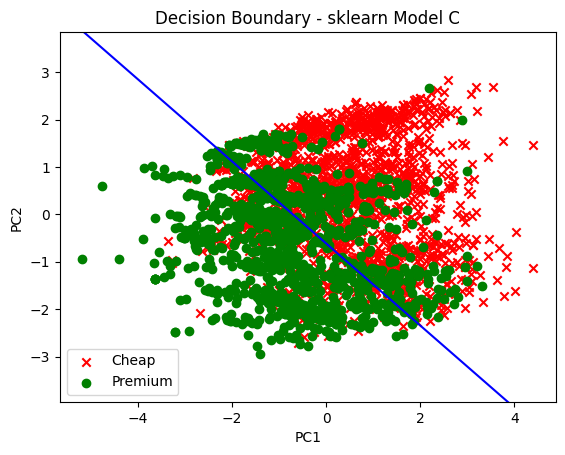

In [58]:
w0_sk_C = model_clf_sk_C.intercept_[0]
w1_sk_C = model_clf_sk_C.coef_[0][0]   # PC1
w2_sk_C = model_clf_sk_C.coef_[0][1]   # PC2

plot_decision_boundary(
    x_tr_pca[:,0], x_tr_pca[:,1], y_clf_tr.values,
    w0_sk_C, w1_sk_C, w2_sk_C,
    "PC1", "PC2", "Decision Boundary - sklearn Model C"
)

## Compare metrics across different preprocessing approaches

In [59]:
# Unified table for the performance of the six models (Custom vs sklearn)
final_summary_df = pd.DataFrame({
    "Model": [
        "Linear A (baseline)", "Linear B (normalized)", "Linear C (norm+PCA)",
        "Logistic A (baseline)", "Logistic B (normalized)", "Logistic C (norm+PCA)"
    ],
    "Preprocessing": [
        "None", "Normalization", "Normalization + PCA",
        "None", "Normalization", "Normalization + PCA"
    ],
    "Main Metric": ["RMSE", "RMSE", "RMSE", "Accuracy", "Accuracy", "Accuracy"],
    "Custom Score": [
        rmse_A, rmse_B, rmse_C,
        accuracy_A, accuracy_B, accuracy_C
    ],
    "sklearn Score": [
        rmse_sk_A, rmse_sk_B, rmse_sk_C,
        accuracy_sk_A, accuracy_sk_B, accuracy_sk_C
    ]
})

final_summary_df

,Model,Preprocessing,Main Metric,Custom Score,sklearn Score
0,Linear A (baseline),None,RMSE,352458.377127,156443.586956
1,Linear B (normalized),Normalization,RMSE,156443.599067,156443.586956
2,Linear C (norm+PCA),Normalization + PCA,RMSE,159162.051822,159162.051822
3,Logistic A (baseline),None,Accuracy,0.567692,0.826154
4,Logistic B (normalized),Normalization,Accuracy,0.818462,0.821538
5,Logistic C (norm+PCA),Normalization + PCA,Accuracy,0.818462,0.820000


### Custom vs. sklearn — Visual Comparison
This chart shows that our custom model was way off from sklearn in Model A, but almost matched it after normalization in Models B and C. This proves our from-scratch implementation is correct — it just needed properly scaled data to perform well.

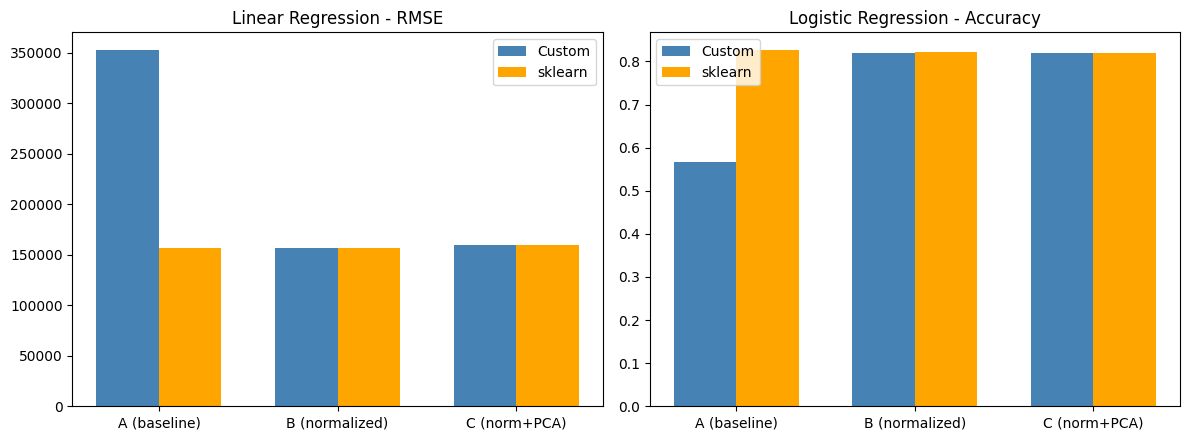

In [60]:
labels = ["A (baseline)", "B (normalized)", "C (norm+PCA)"]
x = np.arange(3)
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# First plot: RMSE (Linear Regression)
rmse_custom = [rmse_A, rmse_B, rmse_C]
rmse_sklearn = [rmse_sk_A, rmse_sk_B, rmse_sk_C]

axes[0].bar(x - width/2, rmse_custom, width, label="Custom", color="steelblue")
axes[0].bar(x + width/2, rmse_sklearn, width, label="sklearn", color="orange")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_title("Linear Regression - RMSE")
axes[0].legend()

# Second plot: Accuracy (Logistic Regression)
acc_custom = [accuracy_A, accuracy_B, accuracy_C]
acc_sklearn = [accuracy_sk_A, accuracy_sk_B, accuracy_sk_C]

axes[1].bar(x - width/2, acc_custom, width, label="Custom", color="steelblue")
axes[1].bar(x + width/2, acc_sklearn, width, label="sklearn", color="orange")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_title("Logistic Regression - Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

## ⚙️ Impact of Preprocessing

- 📏 **Normalization:**  
  Had the biggest impact. Performance improved from **57% → 82%** because Gradient Descent converged properly.

- 🔻 **PCA:**  
  Had a minor effect. Reducing features **16 → 14** kept similar performance:
  - RMSE: **156K → 159K**
  - Accuracy: **82% → 82%**

- ⚖️ **Trade-off:**  
  PCA reduced model complexity with minimal information loss, making it a good choice.

## 3. Custom vs. Library Model Comparison 
- IMPORTANT: For both Linear Regression and Logistic Regression, students must: 
* Implement scikit-learn models for comparison: 
* Use sklearn.linear_model.LinearRegression for regression tasks 
* Use sklearn.linear_model.LogisticRegression for classification tasks

In [61]:
# Difference = our custom model's score minus the sklearn model's score
final_summary_df["Difference"] = (
    final_summary_df["Custom Score"] - final_summary_df["sklearn Score"]
)

print("=== Custom vs sklearn - Baseline ===")
display(final_summary_df[final_summary_df["Preprocessing"] == "None"])

print("\n=== Custom vs sklearn - Normalized ===")
display(final_summary_df[final_summary_df["Preprocessing"] == "Normalization"])

print("\n=== Custom vs sklearn - Normalization + PCA ===")
display(final_summary_df[final_summary_df["Preprocessing"] == "Normalization + PCA"])

=== Custom vs sklearn - Baseline ===


,Model,Preprocessing,Main Metric,Custom Score,sklearn Score,Difference
0,Linear A (baseline),None,RMSE,352458.377127,156443.586956,196014.790172
3,Logistic A (baseline),None,Accuracy,0.567692,0.826154,-0.258462



=== Custom vs sklearn - Normalized ===


,Model,Preprocessing,Main Metric,Custom Score,sklearn Score,Difference
1,Linear B (normalized),Normalization,RMSE,156443.599067,156443.586956,0.012111
4,Logistic B (normalized),Normalization,Accuracy,0.818462,0.821538,-0.003077



=== Custom vs sklearn - Normalization + PCA ===


,Model,Preprocessing,Main Metric,Custom Score,sklearn Score,Difference
2,Linear C (norm+PCA),Normalization + PCA,RMSE,159162.051822,159162.051822,-2.910383e-11
5,Logistic C (norm+PCA),Normalization + PCA,Accuracy,0.818462,0.820000,-1.538462e-03


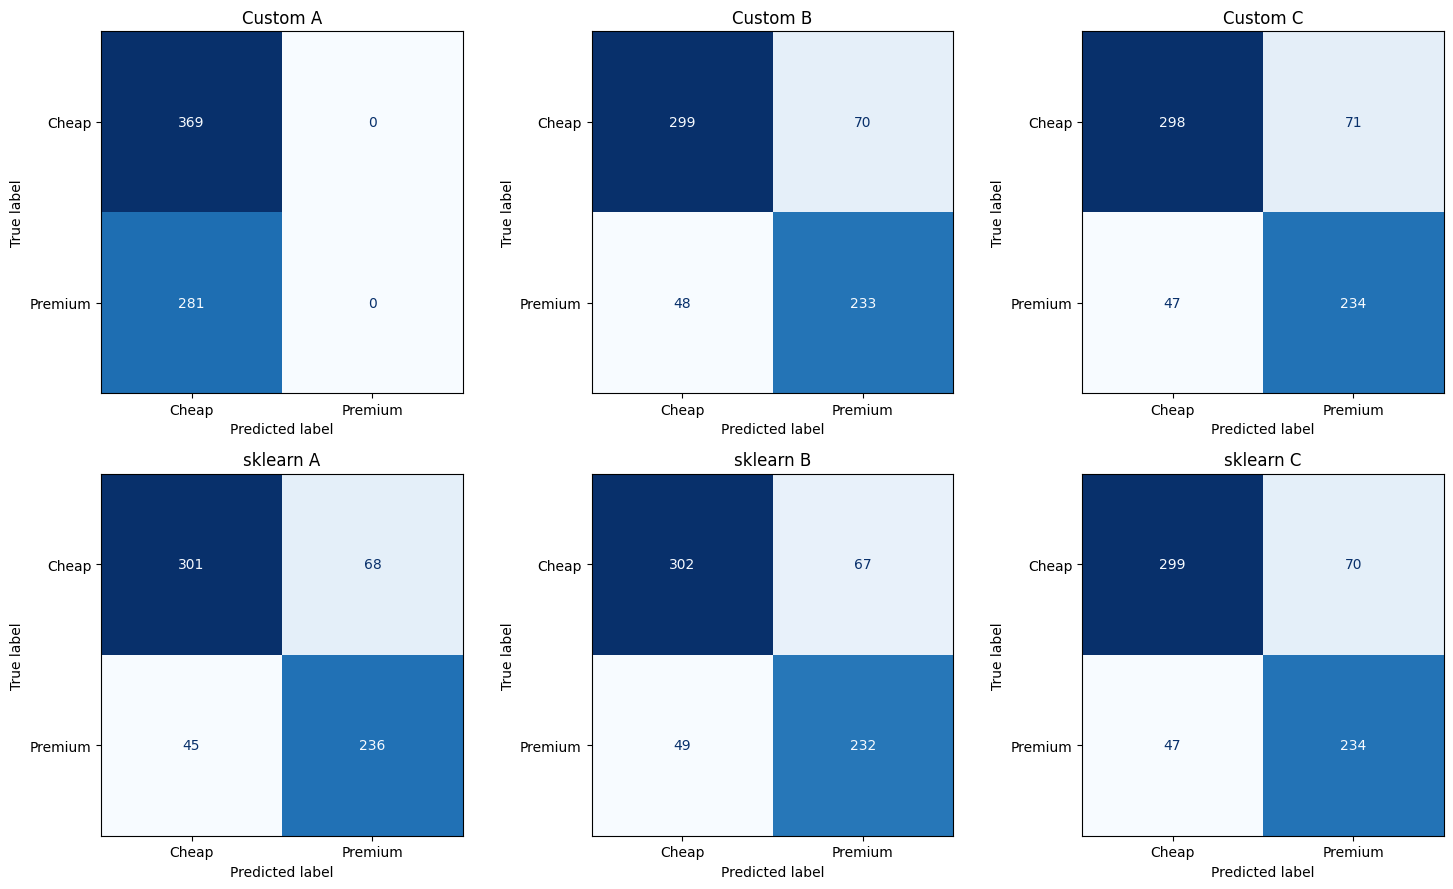

In [62]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

preds = [pred_A_clf, pred_B_clf, pred_C_clf, pred_clf_sk_A, pred_clf_sk_B, pred_clf_sk_C]
titles = ["Custom A", "Custom B", "Custom C", "sklearn A", "sklearn B", "sklearn C"]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, pred, title in zip(axes.flatten(), preds, titles):
    cm = confusion_matrix(y_clf_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=["Cheap", "Premium"]).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(title)

plt.tight_layout()
plt.show()

## 📊 Custom Models vs Scikit-Learn Comparison

### Baseline (Unscaled Data)
- Large performance gap:
  - Linear Regression: RMSE difference ≈ **196,000**
  - Logistic Regression: Accuracy was **25.8% lower**
- Reason: Gradient Descent struggled with unscaled features and did not fully converge.

### Normalized Data
- The gap almost disappeared:
  - RMSE difference ≈ **0**
  - Accuracy difference ≈ **0.3%**
- This confirms that our custom implementations are mathematically correct.

### Normalized + PCA
- Both models achieved almost identical results to Scikit-Learn.
- Small differences are due to floating-point precision.

## 🎯 Final Takeaway
The main issue was not the implementation itself, but the effect of unscaled features on Gradient Descent.

After normalization (and PCA), our custom models performed almost the same as Scikit-Learn.

## 🔍 Analysis & Discussion

**Performance Gap:**  
The gap was large with unscaled data, but almost disappeared after normalization and PCA.

**Reason:**  
Gradient Descent is sensitive to feature scaling, while Scikit-Learn uses optimized solvers.

**Validation:**  
Similar results after preprocessing confirm that our custom implementation is correct.

**Strengths & Weaknesses:**  
Custom models provide better understanding and control, but are slower and require parameter tuning compared to Scikit-Learn.

## 💡 Observations & Insights

**Best Performance:**  
Normalization + PCA achieved the best results with the most stable performance.

**Custom vs Scikit-Learn:**  
Our models matched Scikit-Learn closely after proper preprocessing.

**Key Finding:**  
Feature scaling had a major impact on Gradient Descent performance.

**Future Improvements:**  
Tune hyperparameters and use more advanced optimization techniques.

In [63]:
# ===== Kernel SVM (non-linear, handles class imbalance) =====
from sklearn import svm
from sklearn.metrics import accuracy_score, classification_report

svm_bal = svm.SVC(kernel="rbf", class_weight="balanced")
svm_bal.fit(x_tr_norm, y_clf_tr)
pred_svm = svm_bal.predict(x_test_norm)
print("Kernel SVM Accuracy:", accuracy_score(y_clf_test, pred_svm))
print(classification_report(y_clf_test, pred_svm))



Kernel SVM Accuracy: 0.82
              precision    recall  f1-score   support

           0       0.90      0.76      0.83       369
           1       0.74      0.89      0.81       281

    accuracy                           0.82       650
   macro avg       0.82      0.83      0.82       650
weighted avg       0.83      0.82      0.82       650



In [64]:
from sklearn import svm
from sklearn.metrics import confusion_matrix, classification_report

# Same normalized data (Z-score) used for Model B
model_svm = svm.SVC(kernel="rbf")
model_svm.fit(x_tr_norm, y_clf_tr)
pred_svm = model_svm.predict(x_test_norm)

cm_svm = confusion_matrix(pred_svm, y_clf_test)
print(cm_svm)
print(classification_report(pred_svm, y_clf_test))

acc_svm = (pred_svm == y_clf_test).mean()
print("SVM (RBF) accuracy:", acc_svm)

[[296  41]
 [ 73 240]]
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       337
           1       0.85      0.77      0.81       313

    accuracy                           0.82       650
   macro avg       0.83      0.82      0.82       650
weighted avg       0.83      0.82      0.82       650

SVM (RBF) accuracy: 0.8246153846153846


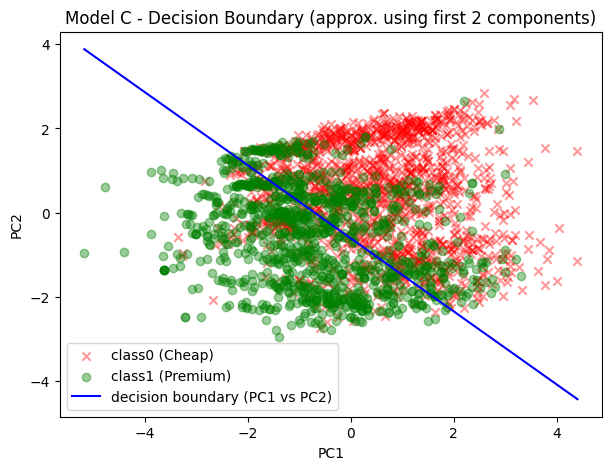

In [65]:
#Decision boundary visualization
#Since we have many features we can't plot a boundary in the original space,
#so we use the first 2 Principal Components (PC1, PC2) of Model C as a 2D approximation

x_class0 = x_tr_pca[np.array(y_clf_tr)==0]
x_class1 = x_tr_pca[np.array(y_clf_tr)==1]

plt.figure(figsize=(7,5))
plt.scatter(x_class0[:,0], x_class0[:,1], color="r", marker="x", label="class0 (Cheap)", alpha=0.4)
plt.scatter(x_class1[:,0], x_class1[:,1], color="g", marker="o", label="class1 (Premium)", alpha=0.4)

#the line uses only the weights of PC1 and PC2 (w_clf_C[1] and w_clf_C[2]), same idea as the Basmala notebook
pc1_range = np.linspace(x_tr_pca[:,0].min(), x_tr_pca[:,0].max(), 100)
pc2_line = -(w_clf_C[0] + w_clf_C[1]*pc1_range) / w_clf_C[2]
plt.plot(pc1_range, pc2_line, color="b", label="decision boundary (PC1 vs PC2)")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Model C - Decision Boundary (approx. using first 2 components)")
plt.legend()
plt.show()


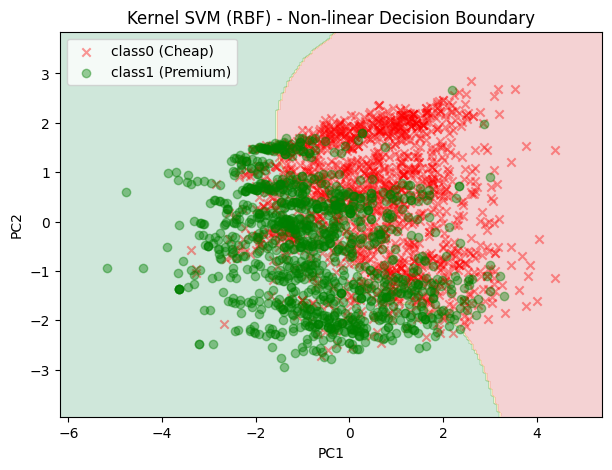

In [66]:
# To see the shape of the non-linear boundary, we train another SVM using only PC1 and PC2 (2D) so we can plot it
model_svm_2d = svm.SVC(kernel="rbf")
model_svm_2d.fit(x_tr_pca[:, :2], y_clf_tr)

x_min, x_max = x_tr_pca[:,0].min()-1, x_tr_pca[:,0].max()+1
y_min, y_max = x_tr_pca[:,1].min()-1, x_tr_pca[:,1].max()+1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
zz = model_svm_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(7,5))
plt.contourf(xx, yy, zz, alpha=0.2, cmap="RdYlGn")   # Colored region = model predictions

plt.scatter(x_class0[:,0], x_class0[:,1], color="r", marker="x", label="class0 (Cheap)", alpha=0.4)
plt.scatter(x_class1[:,0], x_class1[:,1], color="g", marker="o", label="class1 (Premium)", alpha=0.4)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Kernel SVM (RBF) - Non-linear Decision Boundary")
plt.legend()
plt.show()

In [67]:
# ===== Random Forest (non-linear, for comparison) =====
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

rf_clf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced")
rf_clf.fit(x_tr_norm, y_clf_tr)
pred_rf = rf_clf.predict(x_test_norm)
print("\nRandom Forest Accuracy:", accuracy_score(y_clf_test, pred_rf))

rf_reg = RandomForestRegressor(n_estimators=300, random_state=42)
rf_reg.fit(x_reg_tr, y_reg_tr)
pred_rf_reg = rf_reg.predict(x_reg_test)
rmse_rf = np.sqrt(np.mean((pred_rf_reg - y_reg_test)**2))
print("Random Forest RMSE:", rmse_rf)


Random Forest Accuracy: 0.8153846153846154
Random Forest RMSE: 156296.89502932454
